In [17]:
from datetime import datetime, timedelta
from cycler import cycler
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pytimber
import pickle
import os

os.makedirs("cache", exist_ok=True)

In [18]:
# Amenities
# Define the color looping scheme for plt from a series of hex colors
colors = ['#3f90da','#ffa90e','#bd1f01','#94a4a2','#832db6','#a96b59','#e76300','#b9ac70','#717581','#92dadd']

In [19]:
# Get fills with SB declared in the last 3 days
# Define time window 
# For specific time use datetime(2024, 6, 1, 12, 0, 0) for example (year, month, day, hour, minute, second)
# t_end = datetime.now() # End time is current time minus 5 minutes to ensure data availability
t_end = datetime(2026, 5, 12, 10, 0, 0) # End time is current time minus 5 minutes to ensure data availability
t_start = t_end - timedelta(days=3)
print(f"Time window for fill selection: {t_start} to {t_end}")

Time window for fill selection: 2026-05-09 10:00:00 to 2026-05-12 10:00:00


In [20]:
# Create LoggingDB object
ldb = pytimber.LoggingDB(source="nxcals")

In [21]:
fill_list = ldb.get_interval_by_lhc_modes(t_start, t_end, mode1='STABLE', mode2='STABLE')

print('Fills to process:')
for fill in fill_list:
    sb_start = datetime.fromtimestamp(fill.modeFirstAttribute)
    sb_end = datetime.fromtimestamp(fill.modeSecondAttribute)
    n = fill.fillNumber
    print(f"\tFill {n} has SB from {sb_start} to {sb_end}")

/afs/cern.ch/user/a/abellora/workarea/Work/CT-PPS/pps-timber/venv/lib64/python3.9/site-packages/pytimber/utils.py:93: UserWarning: Discarding nonzero nanoseconds in conversion.
  return pd.to_datetime(nanos, unit="ns", utc=utc).to_pydatetime()


Fills to process:
	Fill 11715 has SB from 2026-05-08 21:49:30.617488 to 2026-05-09 13:13:04.911613
	Fill 11717 has SB from 2026-05-09 17:55:51.864238 to 2026-05-10 03:19:43.043488
	Fill 11718 has SB from 2026-05-10 05:19:36.065863 to 2026-05-10 11:26:54.617738
	Fill 11720 has SB from 2026-05-10 16:40:07.007863 to 2026-05-11 06:05:41.065613
	Fill 11723 has SB from 2026-05-11 11:53:57.909738 to 2026-05-11 18:38:47.852738
	Fill 11724 has SB from 2026-05-12 00:00:13.311488 to 2026-05-12 14:15:35.071738


In [22]:
pps_rp_name_map = {
    "45-220-fr-hr": "B6L5.B2",
    "45-220-cyl-hr": "E6L5.B2",
    "45-220-nr-hr": "A6L5.B2",
    "45-210-fr-hr": "D6L5.B2",
    "56-220-fr-hr": "B6R5.B1",
    "56-220-cyl-hr": "E6R5.B1",
    "56-220-nr-hr": "A6R5.B1",
    "56-210-fr-hr": "D6R5.B1"
}

variables = [
    "LHC.BCTDC.A6R4.B1:BEAM_INTENSITY",
    "LHC.BQM.B1:BUNCH_LENGTH_MEAN",
    "LHC.BCTDC.A6R4.B2:BEAM_INTENSITY",
    "LHC.BQM.B2:BUNCH_LENGTH_MEAN",
    "LHC.BCTFR.B6R4.B1:BUNCH_COUNT",
    "LHC.BCTFR.B6R4.B2:BUNCH_COUNT",
]

for rp, timber_name in pps_rp_name_map.items():
    if timber_name.startswith("E"):
        variables.append(f"XRPH.{timber_name}:LU:TEMPFLOUT")
    else:
        variables.append(f"XRPH.{timber_name}:TEMPFLOUT")
    variables.append(f"XRPH.{timber_name}:MEAS_LIMIT_WARN_INNER_LU")    
    variables.append(f"XRPH.{timber_name}:MEAS_LVDT_LU")
    
print("Variables to retrieve:")
pprint(variables)

Variables to retrieve:
['LHC.BCTDC.A6R4.B1:BEAM_INTENSITY',
 'LHC.BQM.B1:BUNCH_LENGTH_MEAN',
 'LHC.BCTDC.A6R4.B2:BEAM_INTENSITY',
 'LHC.BQM.B2:BUNCH_LENGTH_MEAN',
 'LHC.BCTFR.B6R4.B1:BUNCH_COUNT',
 'LHC.BCTFR.B6R4.B2:BUNCH_COUNT',
 'XRPH.B6L5.B2:TEMPFLOUT',
 'XRPH.B6L5.B2:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.B6L5.B2:MEAS_LVDT_LU',
 'XRPH.E6L5.B2:LU:TEMPFLOUT',
 'XRPH.E6L5.B2:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.E6L5.B2:MEAS_LVDT_LU',
 'XRPH.A6L5.B2:TEMPFLOUT',
 'XRPH.A6L5.B2:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.A6L5.B2:MEAS_LVDT_LU',
 'XRPH.D6L5.B2:TEMPFLOUT',
 'XRPH.D6L5.B2:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.D6L5.B2:MEAS_LVDT_LU',
 'XRPH.B6R5.B1:TEMPFLOUT',
 'XRPH.B6R5.B1:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.B6R5.B1:MEAS_LVDT_LU',
 'XRPH.E6R5.B1:LU:TEMPFLOUT',
 'XRPH.E6R5.B1:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.E6R5.B1:MEAS_LVDT_LU',
 'XRPH.A6R5.B1:TEMPFLOUT',
 'XRPH.A6R5.B1:MEAS_LIMIT_WARN_INNER_LU',
 'XRPH.A6R5.B1:MEAS_LVDT_LU',
 'XRPH.D6R5.B1:TEMPFLOUT',
 'XRPH.D6R5.B1:MEAS_LIMIT_WARN_INNER_LU',
 

In [23]:
def get_t1_data_with_caching(variables, fillInterval):
    fill_to_analyze = fillInterval.fillNumber
    fill_to_analyze_sb_start = datetime.fromtimestamp(fillInterval.modeFirstAttribute)
    fill_to_analyze_sb_end = datetime.fromtimestamp(fillInterval.modeSecondAttribute)

    try:
        with open(f"cache/cached_data_analysis_{fill_to_analyze}_t1.pkl", "rb") as f:
            cached_data = pickle.load(f)
            # Check if cached data matches the current query parameters (variables and time range)
            if (set(variables).issubset(set(cached_data.keys())) and
                't_start' in cached_data and 't_end' in cached_data and
                abs(cached_data['t_start'] - fill_to_analyze_sb_start) <= timedelta(minutes=15) and
                abs(cached_data['t_end'] - fill_to_analyze_sb_end) <= timedelta(minutes=15)):
                print("Using cached data")
                data = cached_data
            else:
                print("Cached data does not match the current query. Querying new data.")

                # Convert to TIMBER time format (seconds since epoch)
                t1 = fill_to_analyze_sb_start.timestamp()
                t2 = fill_to_analyze_sb_end.timestamp()

                data = ldb.get_aligned(variables, t1, t2)
                
                data['t_start'] = fill_to_analyze_sb_start
                data['t_end'] = fill_to_analyze_sb_end
                
                with open(f"cache/cached_data_analysis_{fill_to_analyze}_t1.pkl", "wb") as f:
                    pickle.dump(data, f)
                
    except FileNotFoundError:
        print("No cached data found. Querying new data.")
        # Create LoggingDB object
        ldb = pytimber.LoggingDB(source="nxcals")

        # Convert to TIMBER time format (seconds since epoch)
        t1 = fill_to_analyze_sb_start.timestamp()
        t2 = fill_to_analyze_sb_end.timestamp()

        data = ldb.get_aligned(variables, t1, t2)
        
        data['t_start'] = fill_to_analyze_sb_start
        data['t_end'] = fill_to_analyze_sb_end
        
        # Cache the data for future use
        with open(f"cache/cached_data_analysis_{fill_to_analyze}_t1.pkl", "wb") as f:
            pickle.dump(data, f)
            
    # Make all arrays of the same length by trimming to the shortest one
    min_length = min(len(arr) for arr in data.values() if isinstance(arr, np.ndarray))
    for key in data:
        if isinstance(data[key], np.ndarray) and len(data[key]) > min_length:
            data[key] = data[key][:min_length]

    df_t1 = pd.DataFrame({k: data[k] for k in data if k not in ['t_start', 't_end']})
    df_t1['fill'] = fill.fillNumber
    df_t1['time'] = pd.to_datetime(df_t1['timestamps'],unit='s')
    df_t1['data_tier'] = 'Tier 1'

    return df_t1

In [24]:
# Drop all data with all the *MEAS_LVDT_LU larger than 5
# Create a new df for that

def get_t2_data_with_caching(variables, fillInterval, no_remove_t1=False):
    
    cache_path = f"cache/cached_data_analysis_{fillInterval.fillNumber}_t2.pkl"

    if os.path.exists(cache_path):
        df_t2 = pd.read_pickle(cache_path)
        print(f"Loaded df_t2 from {cache_path}")
    else:
        # Get the t1 data for the fill
        df_t1 = get_t1_data_with_caching(variables, fillInterval)
        df_t2 = df_t1.copy()
        df_t2.to_pickle(cache_path)
        print(f"Cached df_t2 to {cache_path}")
        if not no_remove_t1:
            # Delete t1 cache
            t1_cache_path = f"cache/cached_data_analysis_{fillInterval.fillNumber}_t1.pkl"
            if os.path.exists(t1_cache_path):
                os.remove(t1_cache_path)

    meas_limit_cols = df_t2.filter(regex="MEAS_LVDT_LU")
    mask = (meas_limit_cols > 3).all(axis=1)
    df_t2 = df_t2[~mask]

    df_t2["data_tier"] = "Tier 2"
    return df_t2

In [25]:
# Example to compare the two data tiers
df_t1 = pd.DataFrame()
df_t2 = pd.DataFrame()

for fill in fill_list[:3]:
    print(f"Processing fill {fill.fillNumber}...")
    df_t1 = pd.concat([df_t1,get_t1_data_with_caching(variables, fill)])
    df_t2 = pd.concat([df_t2,get_t2_data_with_caching(variables, fill)])

# Find the total time range covered by the data
overall_start = df_t1['time'].min()
overall_end = df_t1['time'].max()
print(f"Overall time range covered by the data: {overall_start} to {overall_end}")

# Print size info on the two dfs
print(f"Tier 1 dataset size: {df_t1.shape[0]} rows, {df_t1.shape[1]} columns")
print(f"Tier 2 dataset size: {df_t2.shape[0]} rows, {df_t2.shape[1]} columns")

Processing fill 11715...
Using cached data
Using cached data
Cached df_t2 to cache/cached_data_analysis_11715_t2.pkl
Processing fill 11717...
Using cached data
Using cached data
Cached df_t2 to cache/cached_data_analysis_11717_t2.pkl
Processing fill 11718...
Using cached data
Using cached data
Cached df_t2 to cache/cached_data_analysis_11718_t2.pkl
Overall time range covered by the data: 2026-05-08 19:49:30.929425001 to 2026-05-10 09:26:54.490802050
Tier 1 dataset size: 109163 rows, 34 columns
Tier 2 dataset size: 107842 rows, 34 columns


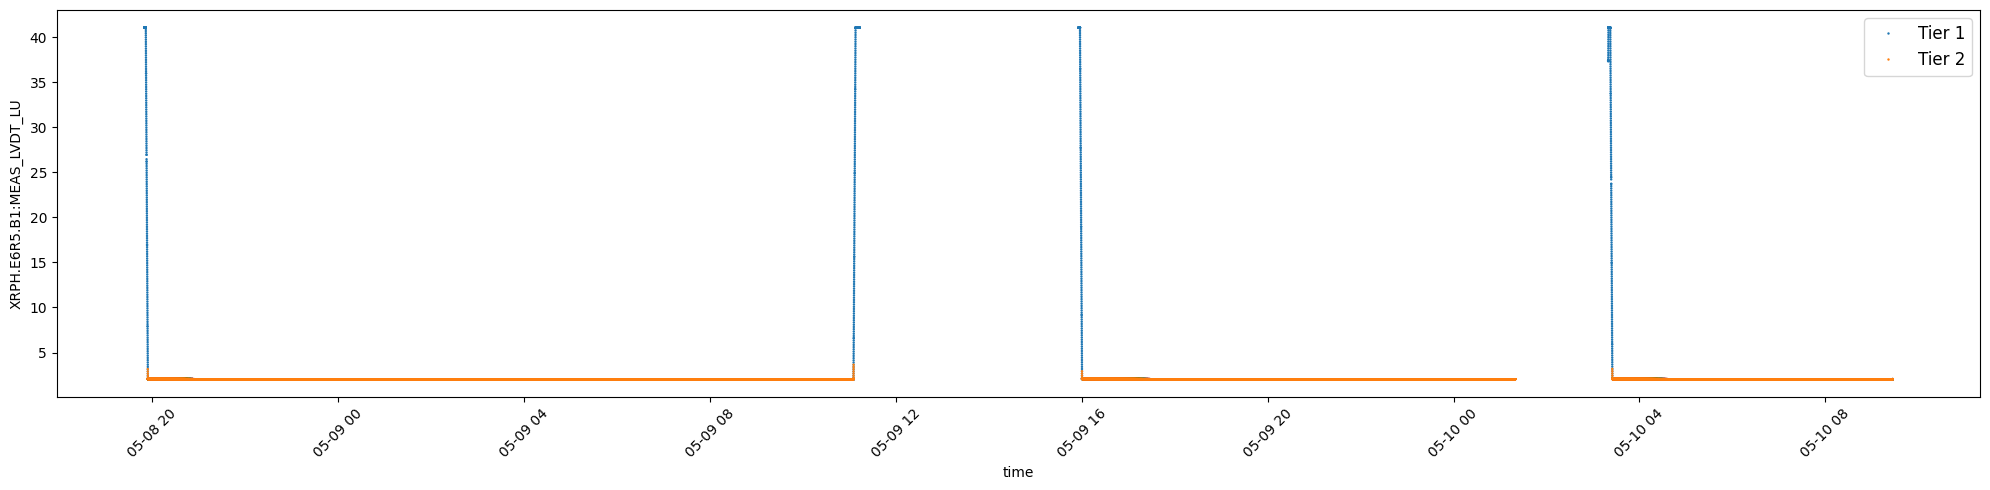

In [26]:
df_all = pd.concat([df_t1, df_t2], ignore_index=True)

plt.figure(figsize=(20, 5))
sns.scatterplot(data=df_all, x="time", y="XRPH.E6R5.B1:MEAS_LVDT_LU", hue='data_tier', s=3, edgecolor=None, linewidth=0)

plt.xticks(rotation=45)
plt.legend(loc='upper right', fontsize='large')
plt.tight_layout()
plt.show()

In [76]:
def make_t3_data(df_t2, no_remove_t2=False):
    lvdt_cols = [c for c in df_t2.columns if 'MEAS_LVDT_LU' in c]
    limit_cols = [c for c in df_t2.columns if 'MEAS_LIMIT_WARN_INNER_LU' in c]

    pairs = {}
    for col in lvdt_cols:
        prefix = col.split(":")[0]
        limit_match = [c for c in limit_cols if c.startswith(prefix)]
        if limit_match:
            pairs[prefix] = (col, limit_match[0])        

    distance_df = pd.DataFrame(index=df_t2.index)
    distance_df['fill'] = df_t2['fill']

    # Compute the absolute distance between the LVDT measurement and the inner limit for each RP
    for prefix, (lvdt, limit) in pairs.items():
        distance_df[prefix+':MIN_DIST_FROM_WARN_LIMIT'] = (df_t2[lvdt] - df_t2[limit]).abs()

    distance_df = distance_df.groupby('fill').min().reset_index()

    # Compute the maximum temperature and the temperature at insertion time
    temp_cols = [c for c in df_t2.columns if "TEMPFLOUT" in c]
    first_vals = df_t2.sort_values("time").groupby("fill")[temp_cols].first()
    max_vals = df_t2.groupby("fill")[temp_cols].max()

    # Compute the start and end times of each fill
    t_start = df_t2.groupby("fill")["time"].first()
    t_end = df_t2.groupby("fill")["time"].last()
    
    # Compute the initial LVDT insertion and warning limit value (15 rows delay seems to be enough, ~15 s)
    nrows_delay = 15
    initial_lvdt = df_t2.groupby("fill").nth(nrows_delay).set_index("fill")[lvdt_cols]
    w_limit = df_t2.groupby("fill").nth(nrows_delay).set_index("fill")[limit_cols]

    # Put everything together
    t_start = t_start.to_frame("time_start")
    t_end = t_end.to_frame("time_end")
    initial_lvdt = initial_lvdt.add_suffix("_initial")
    w_limit = w_limit.add_suffix("_limit")
    max_vals = max_vals.add_suffix("_max")
    first_vals = first_vals.add_suffix("_first")

    tmp_df = (
        max_vals
        .join(first_vals)
        .join(t_start)
        .join(t_end)
        .join(initial_lvdt)
        .join(w_limit)
        .reset_index()
    )

    df_t3 = distance_df.merge(tmp_df.reset_index(), on='fill').reset_index(drop=True).drop(columns=['index'])

    df_t3['data_tier'] = 'Tier 3'
    df_t3 = df_t3.reset_index(drop=True)
    
    if not no_remove_t2:
        # Delete t2 cache
        t2_cache_path = f"cache/cached_data_analysis_{fillInterval.fillNumber}_t2.pkl"
        if os.path.exists(t2_cache_path):
            os.remove(t2_cache_path)
    
    return df_t3

In [77]:
def get_t3_data_with_caching(variables, fillInterval, no_remove_t2=False):
    # Divide the fills in groups of five
    fill_groups = [fill_list[i:i+5] for i in range(0, len(fill_list), 5)]
    df_t3 = pd.DataFrame()

    t3_cache_path = f"cache/cached_data_analysis_t3.pkl"

    if os.path.exists(t3_cache_path):
        with open(t3_cache_path, "rb") as f:
            print("Using cached t3 data")
            df_t3 = pickle.load(f)
    else:
        for group in fill_groups:
            df_t2 = pd.DataFrame()
            for fill in group:
                print(f"Processing fill {fill.fillNumber}...")
                df_t2 = pd.concat([df_t2,get_t2_data_with_caching(variables, fill)])
            df_t3 = pd.concat([df_t3,make_t3_data(df_t2, no_remove_t2=no_remove_t2)])
        with open(t3_cache_path, "wb") as f:
            pickle.dump(df_t3, f)
    return df_t3

In [79]:
df_t3 = get_t3_data_with_caching(variables, fill_list, no_remove_t2=True)
df_t3

Processing fill 11715...
Loaded df_t2 from cache/cached_data_analysis_11715_t2.pkl
Processing fill 11717...
Loaded df_t2 from cache/cached_data_analysis_11717_t2.pkl
Processing fill 11718...
Loaded df_t2 from cache/cached_data_analysis_11718_t2.pkl
Processing fill 11720...
Loaded df_t2 from cache/cached_data_analysis_11720_t2.pkl
Processing fill 11723...
Loaded df_t2 from cache/cached_data_analysis_11723_t2.pkl
Processing fill 11724...
Loaded df_t2 from cache/cached_data_analysis_11724_t2.pkl


,fill,XRPH.E6R5.B1:MIN_DIST_FROM_WARN_LIMIT,XRPH.A6L5.B2:MIN_DIST_FROM_WARN_LIMIT,XRPH.B6R5.B1:MIN_DIST_FROM_WARN_LIMIT,XRPH.B6L5.B2:MIN_DIST_FROM_WARN_LIMIT,XRPH.D6R5.B1:MIN_DIST_FROM_WARN_LIMIT,XRPH.E6L5.B2:MIN_DIST_FROM_WARN_LIMIT,XRPH.D6L5.B2:MIN_DIST_FROM_WARN_LIMIT,XRPH.A6R5.B1:MIN_DIST_FROM_WARN_LIMIT,XRPH.B6R5.B1:TEMPFLOUT_max,...,XRPH.A6R5.B1:MEAS_LVDT_LU_initial,XRPH.B6R5.B1:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.A6R5.B1:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.D6L5.B2:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.E6L5.B2:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.E6R5.B1:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.D6R5.B1:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.A6L5.B2:MEAS_LIMIT_WARN_INNER_LU_limit,XRPH.B6L5.B2:MEAS_LIMIT_WARN_INNER_LU_limit,data_tier
0,11715,0.081557,0.076548,0.039559,0.058640,0.009058,0.051437,0.043361,0.004570,57.776737,...,1.885502,1.413,1.809,1.761,1.726,1.942,2.094001,1.711,1.532,Tier 3
1,11717,0.087383,0.065770,0.051087,0.058022,0.023009,0.044967,0.034147,0.068938,52.917164,...,1.887480,1.413,1.759,1.761,1.726,1.942,2.094001,1.711,1.532,Tier 3
2,11718,0.085593,0.053952,0.033279,0.061882,0.018715,0.047609,0.037149,0.056616,55.617050,...,1.870546,1.413,1.759,1.761,1.726,1.942,2.094001,1.711,1.532,Tier 3
3,11720,0.090830,0.065654,0.035446,0.065290,0.018651,0.053611,0.036960,0.054857,56.627197,...,1.883710,1.413,1.759,1.761,1.726,1.942,2.094001,1.711,1.532,Tier 3
4,11723,0.094745,0.062715,0.034489,0.060395,0.013499,0.048486,0.036949,0.057768,55.921848,...,1.884423,1.413,1.759,1.761,1.726,1.942,2.094001,1.711,1.532,Tier 3
0,11723,0.089269,0.073473,0.034646,0.068463,0.021515,0.059021,0.054296,0.060763,54.332180,...,1.885083,1.413,1.759,1.761,1.726,1.942,2.094001,1.711,1.532,Tier 3


In [80]:
print('Tier 3 dataframe structure:')
print(df_t3.info())

Tier 3 dataframe structure:
<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 0 to 0
Data columns (total 44 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   fill                                         6 non-null      int64         
 1   XRPH.E6R5.B1:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 2   XRPH.A6L5.B2:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 3   XRPH.B6R5.B1:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 4   XRPH.B6L5.B2:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 5   XRPH.D6R5.B1:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 6   XRPH.E6L5.B2:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 7   XRPH.D6L5.B2:MIN_DIST_FROM_WARN_LIMIT        6 non-null      float64       
 8   XRPH.A6R5.B1:MIN_DIST_FROM_WARN_LIMIT        6 non-null      

In [81]:
def format_df(df_t3):
    """Better shape for plotting"""

    df_t3 = df_t3.drop(columns=['data_tier'])
    id_cols = ["fill", "time_start", "time_end"]

    df_long = df_t3.melt(
        id_vars=id_cols,
        var_name="raw",
        value_name="value"
    )

    df_long[["xrph", "metric_group"]] = df_long["raw"].str.split(":", n=1, expand=True)
    df_long = df_long.drop(columns=["raw"])

    df_final = df_long.pivot_table(
        index=["fill", "xrph", "time_start", "time_end"],
        columns="metric_group",
        values="value"
    ).reset_index()

    df_final["TEMPFLOUT_first"] = (
        df_final["TEMPFLOUT_first"]
        .combine_first(df_final["LU:TEMPFLOUT_first"])
    )

    df_final["TEMPFLOUT_max"] = (
        df_final["TEMPFLOUT_max"]
        .combine_first(df_final["LU:TEMPFLOUT_max"])
    )

    df_final.drop(columns=["LU:TEMPFLOUT_first", "LU:TEMPFLOUT_max"], inplace=True)

    mapping = {'XRPH.'+v:k for k,v in pps_rp_name_map.items()}
    
    df_final['rp'] = df_final['xrph'].map(mapping)
    df_final['TEMPFLOUT_excursion'] = df_final['TEMPFLOUT_max'] - df_final['TEMPFLOUT_first']
    
    return df_final

In [82]:
plot_df = format_df(df_t3)
plot_df

metric_group,fill,xrph,time_start,time_end,MEAS_LIMIT_WARN_INNER_LU_limit,MEAS_LVDT_LU_initial,MIN_DIST_FROM_WARN_LIMIT,TEMPFLOUT_first,TEMPFLOUT_max,rp,TEMPFLOUT_excursion
0,11715,XRPH.A6L5.B2,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.711000,1.829677,0.076548,27.773256,55.711643,45-220-nr-hr,27.938387
1,11715,XRPH.A6R5.B1,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.809000,1.885502,0.004570,26.064230,57.408630,56-220-nr-hr,31.344400
2,11715,XRPH.B6L5.B2,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.532000,1.624675,0.058640,24.573425,54.300236,45-220-fr-hr,29.726810
3,11715,XRPH.B6R5.B1,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.413000,1.527857,0.039559,25.991405,57.776737,56-220-fr-hr,31.785332
4,11715,XRPH.D6L5.B2,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.761000,1.855359,0.043361,26.066988,55.014309,45-210-fr-hr,28.947321
5,11715,XRPH.D6R5.B1,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,2.094001,2.180229,0.009058,23.496367,56.107239,56-210-fr-hr,32.610872
6,11715,XRPH.E6L5.B2,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.726000,1.833410,0.051437,27.783178,62.081940,45-220-cyl-hr,34.298761
7,11715,XRPH.E6R5.B1,2026-05-08 19:54:00.919595003,2026-05-09 11:05:20.128192902,1.942000,2.065344,0.081557,24.505606,37.447838,56-220-cyl-hr,12.942232
8,11717,XRPH.A6L5.B2,2026-05-09 16:00:15.548192024,2026-05-10 01:19:42.447305918,1.711000,1.819927,0.065770,28.014996,57.678463,45-220-nr-hr,29.663467
9,11717,XRPH.A6R5.B1,2026-05-09 16:00:15.548192024,2026-05-10 01:19:42.447305918,1.759000,1.887480,0.068938,25.577246,52.288521,56-220-nr-hr,26.711275


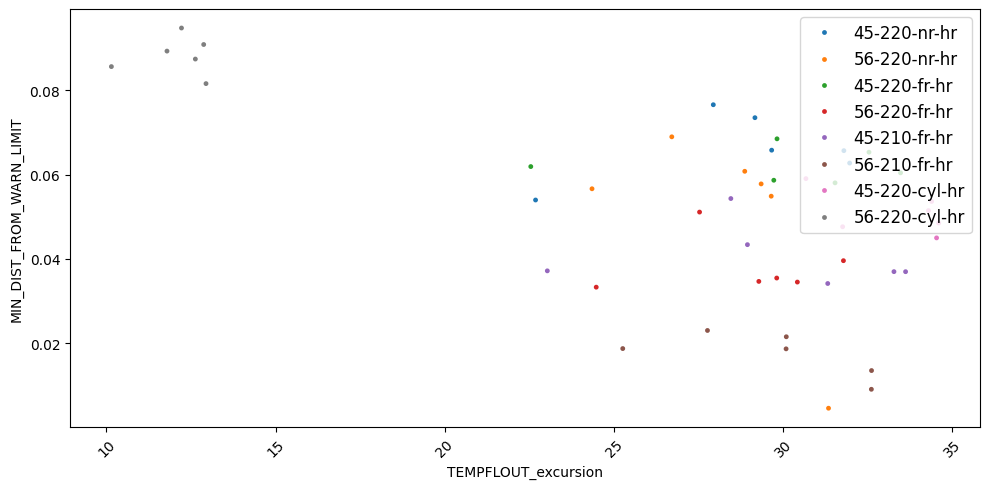

In [83]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=plot_df, x="TEMPFLOUT_excursion", y="MIN_DIST_FROM_WARN_LIMIT", hue='rp', s=12, edgecolor=None, linewidth=0)

plt.xticks(rotation=45)
plt.legend(loc='upper right', fontsize='large')
plt.tight_layout()
plt.show()